# DeepExtractor: Minimal Example

This notebook shows the core DeepExtractor workflow in the simplest possible way:
one noise realization, one sine-Gaussian wavelet injected at SNR=20, reconstructed by the model, and plotted.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import deepextractor
from deepextractor.generation.glitch_functions import generate_sine_gaussian
from deepextractor.generation.generate_timeseries import generate_gaussian_noise, SNR_SCALING_FACTOR_BILBY
from deepextractor.utils.signal import whitened_snr_scaling

In [2]:
SAMPLE_RATE = 4096
T = 2.0                        # total duration (seconds)
LENGTH = int(T * SAMPLE_RATE)  # 8192 samples
T_INJ = T / 2                  # inject signal at midpoint
SNR = 20
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## Step 1 — Generate noise and inject a sine-Gaussian wavelet

In [3]:
# One realization of bilby-simulated noise (whitened L1 strain)
noise = generate_gaussian_noise(0, np.sqrt(SAMPLE_RATE), 1, (LENGTH,), bilby_noise=True)[0]

Generating bilby noise...: 100%|██████████| 1/1 [00:00<00:00, 242.47it/s]


In [4]:
# Generate a sine-Gaussian wavelet (0.5 s duration, max frequency 64 Hz)
_, wavelet = generate_sine_gaussian(duration=0.5, freq_max=64)
wavelet = wavelet - np.mean(wavelet)        # remove DC offset
wavelet = whitened_snr_scaling(wavelet, snr=SNR / SNR_SCALING_FACTOR_BILBY)  # scale to SNR=20 in bilby frame

# Inject into noise at the midpoint
len_glitch = len(wavelet)
id_start = int(T_INJ * SAMPLE_RATE) - len_glitch // 2

noisy_glitch = noise.copy()
noisy_glitch[id_start : id_start + len_glitch] += wavelet

# Ground-truth: the injected signal zero-padded to full length
injected = noisy_glitch - noise

## Step 2 — Load the DeepExtractor model

In [5]:
# Downloads weights automatically from Hugging Face Hub if not cached locally.
# The scaler is loaded from assets/scaler_bilby.pkl automatically.
model = deepextractor.DeepExtractorModel(device=DEVICE)
print(f"Model loaded on: {model.device}")

/opt/homebrew/Caskroom/miniforge/base/envs/deepextractor/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/deepextractor/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loaded on: cpu


## Step 3 — Reconstruct with DeepExtractor

`model.reconstruct()` handles the full pipeline internally:
1. Scale the input with the pretrained StandardScaler
2. Compute the STFT (spectrogram) of the noisy input
3. Feed it through the U-Net — the model outputs a clean *background* (noise-only) estimate
4. Inverse STFT → undo scaling → subtract background to recover the signal

In [6]:
reconstructed = model.reconstruct(noisy_glitch)

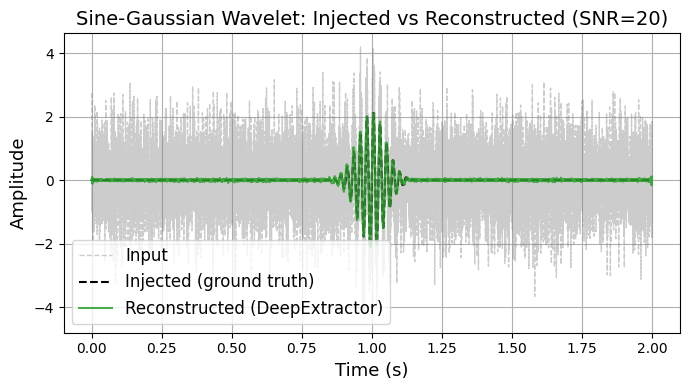

In [7]:
t = np.linspace(0, T, LENGTH)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t, noisy_glitch,      label='Input', color='gray', linestyle='--', linewidth=1, alpha = 0.4)
ax.plot(t, injected,      label='Injected (ground truth)', color='black', linestyle='--', linewidth=1.5)
ax.plot(t, reconstructed, label='Reconstructed (DeepExtractor)', color='C2', linewidth=1.5, alpha=0.85)
ax.set_xlabel('Time (s)', fontsize=13)
ax.set_ylabel('Amplitude', fontsize=13)
ax.set_title('Sine-Gaussian Wavelet: Injected vs Reconstructed (SNR=20)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True)
plt.tight_layout()
plt.show()